In [6]:
from groq import Groq
from sentence_transformers import SentenceTransformer
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

In [7]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [8]:
client = Groq()

In [24]:
from sentence_transformers import SentenceTransformer

# This downloads the lightweight model to your computer once
local_model = SentenceTransformer("all-MiniLM-L6-v2")

def get_embeddings(text, model=None):
    # Generates the vector on your local CPU
    embedding = local_model.encode(text)
    return embedding.tolist()


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2091.26it/s]


In [25]:
sample_texts = [
    "The cat sits on the mat",
    "A feline rests on the carpet",
    "Dogs are great pets",
    "AI is tranforming technology",
    "ML revolutionizes software development"
]

In [28]:
embeddings = []
for text in sample_texts:
    embedding = get_embeddings(text)
    embeddings.append(embedding)
    
    print(f"Text:  {text}")
    print(f"Embedding Length: {len(embedding)}")
    print(f"First 5 values:  {embedding[:5]}")
    print("---------------------------------")

Text:  The cat sits on the mat
Embedding Length: 384
First 5 values:  [0.13489066064357758, -0.032063353806734085, -0.020335247740149498, 0.03590097278356552, -0.028333105146884918]
---------------------------------
Text:  A feline rests on the carpet
Embedding Length: 384
First 5 values:  [0.10853076726198196, -0.014044017530977726, 0.04354557767510414, 0.11785893887281418, -0.02264651656150818]
---------------------------------
Text:  Dogs are great pets
Embedding Length: 384
First 5 values:  [-0.0017497148364782333, -0.024118591099977493, 0.09772291034460068, 0.024500688537955284, -0.10844353586435318]
---------------------------------
Text:  AI is tranforming technology
Embedding Length: 384
First 5 values:  [-0.02791721187531948, -0.01537215244024992, 0.014379346743226051, -0.006870965473353863, -0.013963686302304268]
---------------------------------
Text:  ML revolutionizes software development
Embedding Length: 384
First 5 values:  [-0.01327994279563427, -0.08250924199819565, 0

In [29]:
def calculate_similarity_matrix(embeddings, texts):
    similarity_matrix = cosine_similarity(embeddings)
    
    for i, text in enumerate(texts):
        print(f"{text[:47]:<50}", end = "")
        for j in range(len(texts)):
            print(f"{similarity_matrix[i][j]:.3f}", end = "")
        print()
    return similarity_matrix

In [31]:
similarity = calculate_similarity_matrix(embeddings, sample_texts)

The cat sits on the mat                           1.0000.5610.156-0.024-0.066
A feline rests on the carpet                      0.5611.0000.327-0.013-0.009
Dogs are great pets                               0.1560.3271.0000.0810.085
AI is tranforming technology                      -0.024-0.0130.0811.0000.368
ML revolutionizes software development            -0.066-0.0090.0850.3681.000


In [32]:
from sklearn.decomposition import PCA

In [39]:
def visualize_embeddings(embeddings, texts, title):
    pca = PCA(n_components=2)
    
    embeddings_2d = pca.fit_transform(embeddings)

    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c = range(len(texts)), cmap = "viridis", s = 100)
    
    for i, text in enumerate(texts):
        plt.annotate(f"{i+1}: {text[:25]}...",
                     (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                     xytext= (5, 5), textcoords="offset points")
        
    plt.title(f"{title} - 2d Visualization")
    plt.xlabel("First Principal Component")
    plt.ylabel("Second Principal Component")
    plt.grid(True, alpha = 0.3)
    plt.tight_layout()
    plt.show()

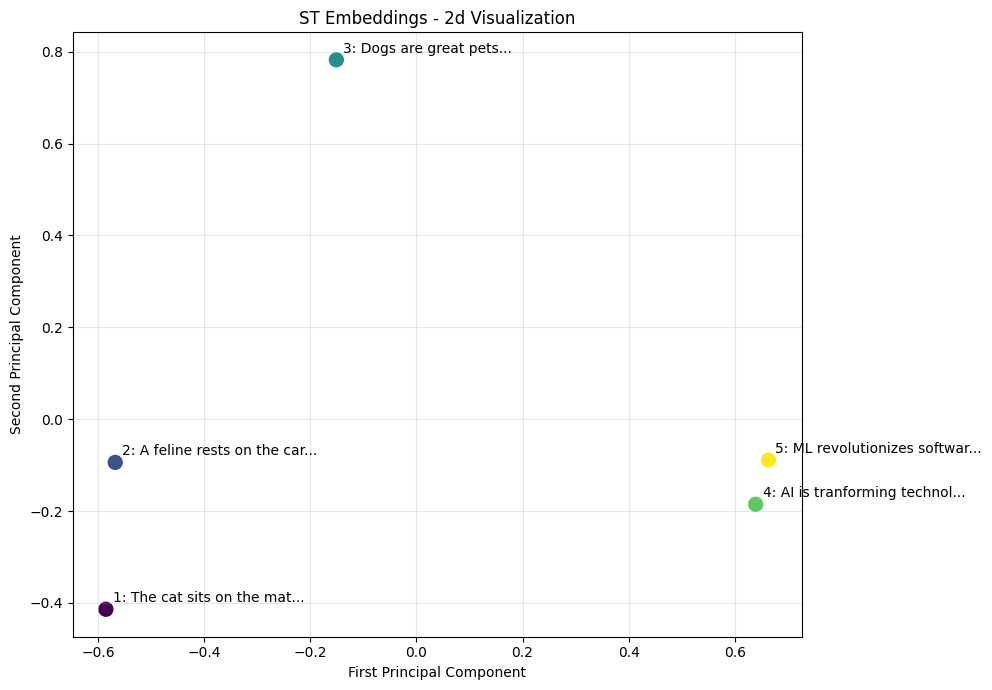

In [40]:
visualize_embeddings(embeddings= embeddings, texts = sample_texts, title = "ST Embeddings")